<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/p4-modif-r%C3%A9duction-du-temps-de-compil/du_sda_ml2_P4_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°4 — Modélisation & Évaluation

Contenu :
- Import des données transformées (sortie du P3)
- Gestion du déséquilibre (Undersampling vs SMOTE)
- Feature Selection
- Comparaison de modèles (Cross-Validation 5-fold)
- Optimisation du meilleur modèle
- Évaluation finale sur le Test Set (une seule fois)
- Interprétabilité et conclusions

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [20]:
train_X = pd.read_parquet("DATA/03_train_X.parquet")
train_y = pd.read_parquet("DATA/03_train_y.parquet").squeeze()
test_X = pd.read_parquet("DATA/03_test_X.parquet")
test_y = pd.read_parquet("DATA/03_test_y.parquet").squeeze()

# Lecture du nom de la cible (pour les fonctions utilitaires)
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Train X : {train_X.shape} | Train y : {train_y.shape}")
print(f"Test  X : {test_X.shape}  | Test  y : {test_y.shape}")
print(f"\nRatio défaut train : {train_y.mean():.2%}")
print(f"Ratio défaut test  : {test_y.mean():.2%}")

Train X : (1166919, 86) | Train y : (1166919,)
Test  X : (291730, 86)  | Test  y : (291730,)

Ratio défaut train : 19.00%
Ratio défaut test  : 19.00%


In [ ]:
from imblearn.over_sampling import SMOTE

# SMOTE "RAM-friendly" pour 16 GB :
# - ratio limité pour éviter de doubler complètement la classe minoritaire
# - k_neighbors plus petit pour réduire le coût de calcul
smote = SMOTE(sampling_strategy=0.35, k_neighbors=3, random_state=42)

# On conserve les noms de variables existants pour ne pas casser la suite du notebook
train_X_under, train_y_under = smote.fit_resample(train_X, train_y)
print(f"SMOTE (ratio=0.35) : {train_X_under.shape}")
print(train_y_under.value_counts())

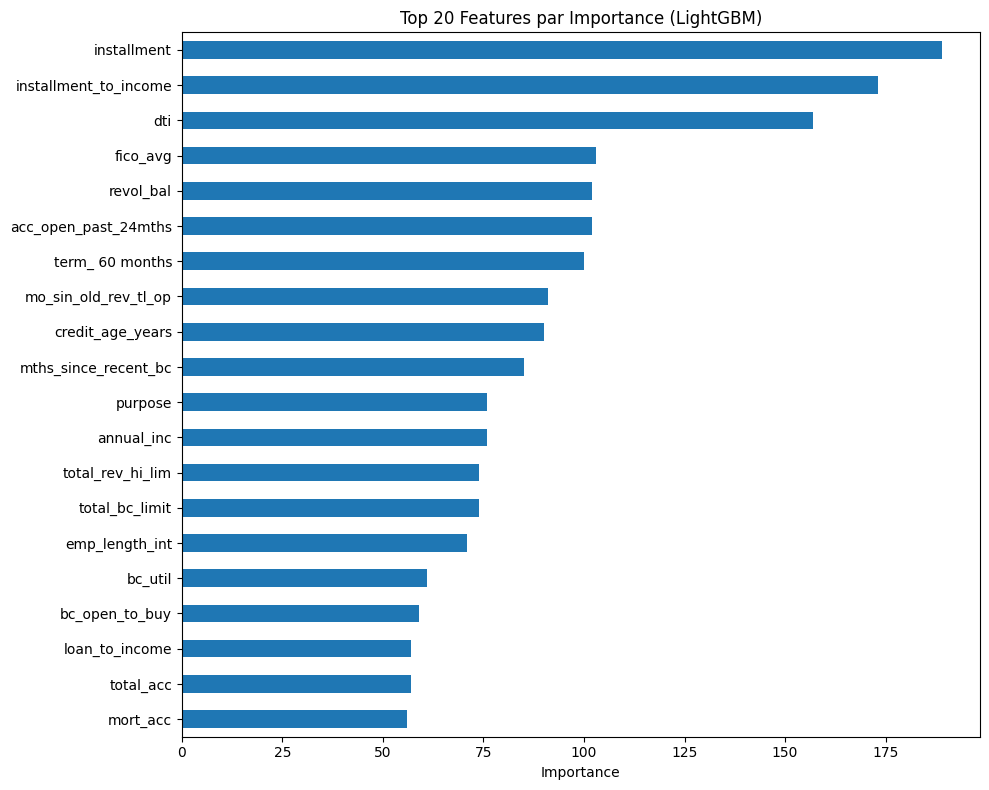


15 features retenues : ['installment', 'installment_to_income', 'dti', 'fico_avg', 'revol_bal', 'acc_open_past_24mths', 'term_ 60 months', 'mo_sin_old_rev_tl_op', 'credit_age_years', 'mths_since_recent_bc', 'purpose', 'annual_inc', 'total_rev_hi_lim', 'total_bc_limit', 'emp_length_int']


In [ ]:
# Méthode : Feature Importance via un modèle LightGBM rapide
from lightgbm import LGBMClassifier

# Entraîner un modèle rapide pour obtenir les importances
lgbm_quick = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm_quick.fit(train_X_under, train_y_under)

# Extraire et afficher les importances
importances = pd.Series(lgbm_quick.feature_importances_, index=train_X_under.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Features par Importance (LightGBM)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Sélectionner les features avec importance > 0 (ou un seuil personnalisé)
N_TOP_FEATURES = 15
vars_final = importances.head(N_TOP_FEATURES).index.tolist()
print(f"\n{N_TOP_FEATURES} features retenues : {vars_final}")

# Filtrer train et test
train_X_under_selected = train_X_under[vars_final]
test_X_selected = test_X[vars_final]

In [ ]:
def calculate_scores(model, X_trn, y_trn, X_tst, y_tst):
    """Entraîne le modèle et calcule les métriques sur le jeu de test."""
    model.fit(X_trn, y_trn)
    y_pred = model.predict(X_tst)
    y_pred_proba = model.predict_proba(X_tst)[:, 1]

    accuracy = accuracy_score(y_tst, y_pred)
    conf_matrix = confusion_matrix(y_tst, y_pred)
    precision = precision_score(y_tst, y_pred)
    recall = recall_score(y_tst, y_pred)
    f1 = f1_score(y_tst, y_pred)
    auc = roc_auc_score(y_tst, y_pred_proba)

    # KS Statistic
    mask = y_tst.astype(bool).values
    ks = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]

    return accuracy, auc, ks, conf_matrix, precision, recall, f1


def calculate_cv_scores(model, X, y, cv=5):
    """Cross-validation stratifiée 5-fold avec métriques complètes."""
    kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    results = {'accuracy': [], 'auc': [], 'ks': [],
               'precision': [], 'recall': [], 'f1': [], 'conf_matrices': []}

    for train_idx, test_idx in kf.split(X, y):
        X_trn, X_tst = X.iloc[train_idx], X.iloc[test_idx]
        y_trn, y_tst = y.iloc[train_idx], y.iloc[test_idx]

        acc, auc, ks, cm, prec, rec, f1 = calculate_scores(
            model, X_trn, y_trn, X_tst, y_tst)

        results['accuracy'].append(acc)
        results['auc'].append(auc)
        results['ks'].append(ks)
        results['conf_matrices'].append(cm)
        results['precision'].append(prec)
        results['recall'].append(rec)
        results['f1'].append(f1)

    return {k: np.mean(v) for k, v in results.items() if k != 'conf_matrices'}, \
           np.mean(results['conf_matrices'], axis=0)


def compare_models(models, X, y, method_name="", cv=5):
    """Compare plusieurs modèles avec CV et retourne un tableau récapitulatif."""
    summary = pd.DataFrame(columns=['accuracy', 'auc', 'ks', 'precision', 'recall', 'f1'])

    for name, model in models.items():
        print(f"  ⏳ {name}...", end="")
        scores, mean_cm = calculate_cv_scores(model, X, y, cv=cv)
        label = f"{name} ({method_name})" if method_name else name
        summary.loc[label] = [scores['accuracy'], scores['auc'], scores['ks'],
                              scores['precision'], scores['recall'], scores['f1']]
        print(f" ✅ AUC={scores['auc']:.4f} | F1={scores['f1']:.4f}")

    return summary

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(min_samples_split=60, min_samples_leaf=30),
    'Random Forest': RandomForestClassifier(n_estimators=100, min_samples_split=60,
                                            min_samples_leaf=30, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Comparaison avec SMOTE
print("=" * 60)
print("COMPARAISON DES MODÈLES — SMOTE")
print("=" * 60)
results_under = compare_models(models, train_X_under_selected, train_y_under,
                                method_name="SMOTE")

COMPARAISON DES MODÈLES — UNDERSAMPLING
  ⏳ Logistic Regression... ✅ AUC=0.6739 | F1=0.6257
  ⏳ Decision Tree... ✅ AUC=0.6240 | F1=0.5852
  ⏳ Random Forest... ✅ AUC=0.6875 | F1=0.6407
  ⏳ LightGBM... ✅ AUC=0.6919 | F1=0.6447
  ⏳ XGBoost... ✅ AUC=0.6916 | F1=0.6429
  ⏳ Gradient Boosting... ✅ AUC=0.6865 | F1=0.6357


In [ ]:
# On sélectionne le meilleur modèle d'après les résultats de la section précédente
# pour l'optimiser avec RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entraîner sur le jeu undersamplé
# Entraîner sur le jeu undersamplé
search.fit(train_X_under_selected, train_y_under)

print(f"\nMeilleurs paramètres : {search.best_params_}")
print(f"Meilleur AUC (CV) : {search.best_score_:.4f}")

best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs paramètres : {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleur AUC (CV) : 0.6960


RAPPORT DE CLASSIFICATION FINAL (TEST SET)
              precision    recall  f1-score   support

   Good Loan       0.89      0.63      0.73    236307
    Bad Loan       0.29      0.65      0.40     55423

    accuracy                           0.63    291730
   macro avg       0.59      0.64      0.57    291730
weighted avg       0.77      0.63      0.67    291730



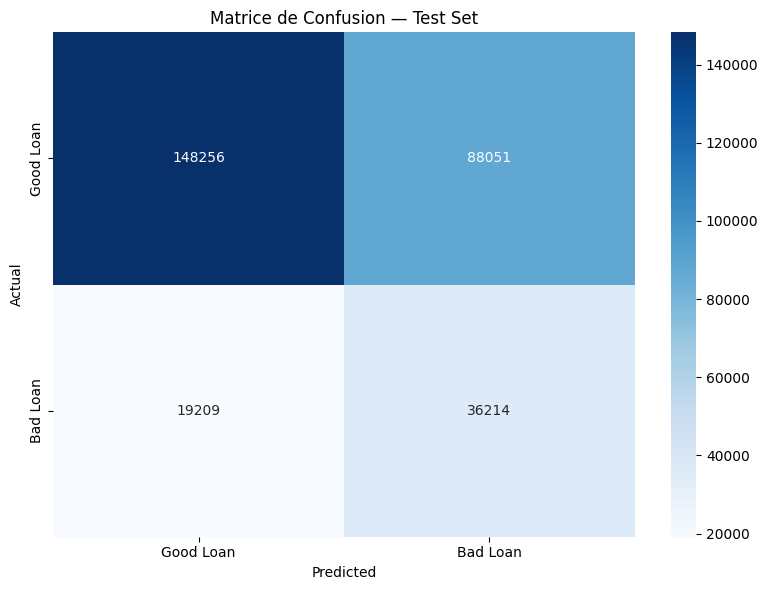

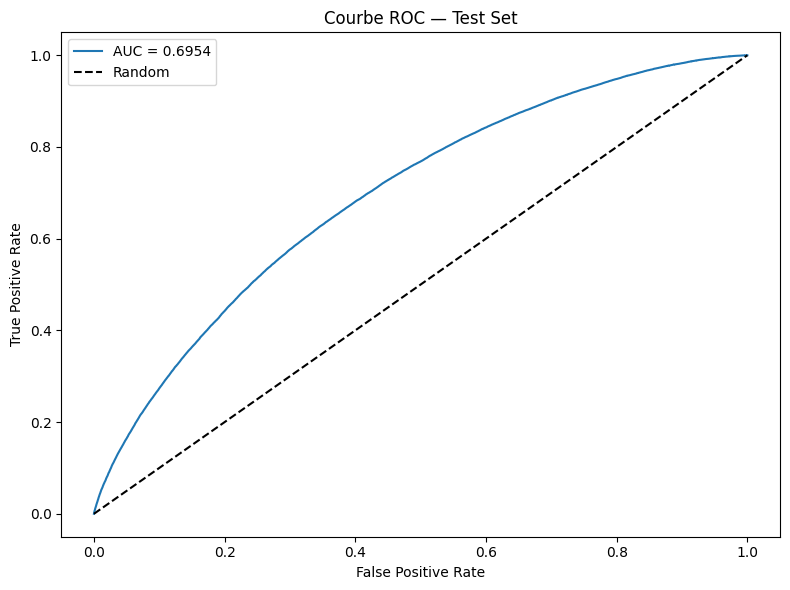

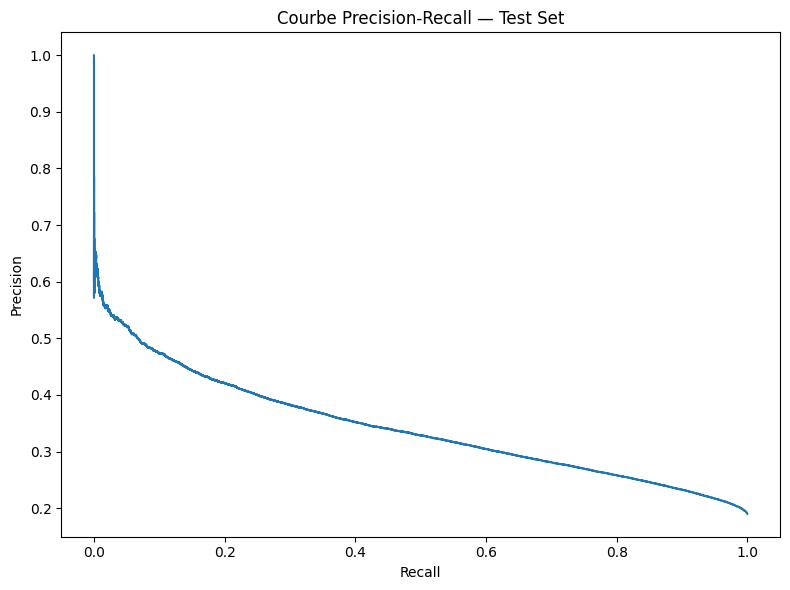


RÉSUMÉ COMPLET DES MÉTRIQUES - TEST SET

📊 MÉTRIQUES GLOBALES
--------------------------------------------------------------------------------
Accuracy                : 0.6323
AUC-ROC                 : 0.6954
KS Statistic            : 0.2812

📈 MÉTRIQUES PAR CLASSE
--------------------------------------------------------------------------------
Classe               Precision       Recall          F1-Score       
-------------------- --------------- --------------- ---------------
Good Loan (0)        0.8853         0.6274         0.7344
Bad Loan (1)         0.2914         0.6534         0.4031

📊 MOYENNES GLOBALES
--------------------------------------------------------------------------------
Métrique             Macro Avg            Weighted Avg        
-------------------- -------------------- --------------------
Precision            0.5884        0.7725
Recall               0.6404        0.6323
F1-Score             0.5687        0.6714


📋 TABLEAU RÉCAPITULATIF
       Class  Prec

In [ ]:
# On établit l'évaluation finale. On n'utilise le test set qu'ici.

y_pred = best_model.predict(test_X_selected)
y_pred_proba = best_model.predict_proba(test_X_selected)[:, 1]

# Classification Report
print("=" * 60)
print("RAPPORT DE CLASSIFICATION FINAL (TEST SET)")
print("=" * 60)
print(classification_report(test_y, y_pred, target_names=['Good Loan', 'Bad Loan']))

# Matrice de confusion
cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matrice de Confusion — Test Set')
plt.tight_layout()
plt.show()

# Courbe ROC
fpr, tpr, _ = roc_curve(test_y, y_pred_proba)
auc_score = roc_auc_score(test_y, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# Courbe Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(test_y, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — Test Set')
plt.tight_layout()
plt.show()

# KS Statistic
mask = test_y.astype(bool).values
ks_stat = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]

# =====================================================================
# ✅ NOUVELLES MÉTRIQUES DÉTAILLÉES
# =====================================================================

# Calcul des métriques par classe
from sklearn.metrics import precision_recall_fscore_support

precision_per_class, recall_per_class, f1_per_class, support = \
    precision_recall_fscore_support(test_y, y_pred, labels=[0, 1])

# Métriques globales (moyennes)
accuracy = accuracy_score(test_y, y_pred)
precision_macro = precision_per_class.mean()
recall_macro = recall_per_class.mean()
f1_macro = f1_per_class.mean()

precision_weighted = precision_score(test_y, y_pred, average='weighted')
recall_weighted = recall_score(test_y, y_pred, average='weighted')
f1_weighted = f1_score(test_y, y_pred, average='weighted')

# Affichage structuré
print("\n" + "=" * 80)
print("RÉSUMÉ COMPLET DES MÉTRIQUES - TEST SET")
print("=" * 80)

print(f"\n📊 MÉTRIQUES GLOBALES")
print("-" * 80)
print(f"Accuracy                : {accuracy:.4f}")
print(f"AUC-ROC                 : {auc_score:.4f}")
print(f"KS Statistic            : {ks_stat:.4f}")

print(f"\n📈 MÉTRIQUES PAR CLASSE")
print("-" * 80)
print(f"{'Classe':<20} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")
print(f"{'-'*20} {'-'*15} {'-'*15} {'-'*15}")
print(f"{'Good Loan (0)':<20} {precision_per_class[0]:.4f}         {recall_per_class[0]:.4f}         {f1_per_class[0]:.4f}")
print(f"{'Bad Loan (1)':<20} {precision_per_class[1]:.4f}         {recall_per_class[1]:.4f}         {f1_per_class[1]:.4f}")

print(f"\n📊 MOYENNES GLOBALES")
print("-" * 80)
print(f"{'Métrique':<20} {'Macro Avg':<20} {'Weighted Avg':<20}")
print(f"{'-'*20} {'-'*20} {'-'*20}")
print(f"{'Precision':<20} {precision_macro:.4f}        {precision_weighted:.4f}")
print(f"{'Recall':<20} {recall_macro:.4f}        {recall_weighted:.4f}")
print(f"{'F1-Score':<20} {f1_macro:.4f}        {f1_weighted:.4f}")

print("\n" + "=" * 80)

# Tableau récapitulatif pour export/analyse
metrics_summary = pd.DataFrame({
    'Class': ['Good Loan', 'Bad Loan', 'Macro Avg', 'Weighted Avg'],
    'Precision': [
        precision_per_class[0],
        precision_per_class[1],
        precision_macro,
        precision_weighted
    ],
    'Recall': [
        recall_per_class[0],
        recall_per_class[1],
        recall_macro,
        recall_weighted
    ],
    'F1-Score': [
        f1_per_class[0],
        f1_per_class[1],
        f1_macro,
        f1_weighted
    ]
})

print("\n📋 TABLEAU RÉCAPITULATIF")
print(metrics_summary.to_string(index=False))

# =====================================================================
# 💡 INTERPRÉTATION MÉTIER
# =====================================================================
print("\n" + "=" * 80)
print("💡 INTERPRÉTATION MÉTIER")
print("=" * 80)
print(f"""
✅ DÉTECTION DES DÉFAUTS (Bad Loan) :
   - Recall = {recall_per_class[1]:.2%}  → Capture {recall_per_class[1]:.0%} des vrais défauts
   - Precision = {precision_per_class[1]:.2%} → Quand on prédit "défaut", c'est vrai {precision_per_class[1]:.0%} du temps

⚠️  ACCEPTATION DE BONS CRÉDITS (Good Loan) :
   - Recall = {recall_per_class[0]:.2%}  → Accepte {recall_per_class[0]:.0%} des vrais bons clients
   - Precision = {precision_per_class[0]:.2%} → Quand on prédit "bon", c'est vrai {precision_per_class[0]:.0%} du temps

📊 PERFORMANCE GLOBALE :
   - AUC-ROC = {auc_score:.4f} → Discrimination entre bon/mauvais crédit
   - KS Stat = {ks_stat:.4f}  → Séparation des distributions
""")
print("=" * 80)

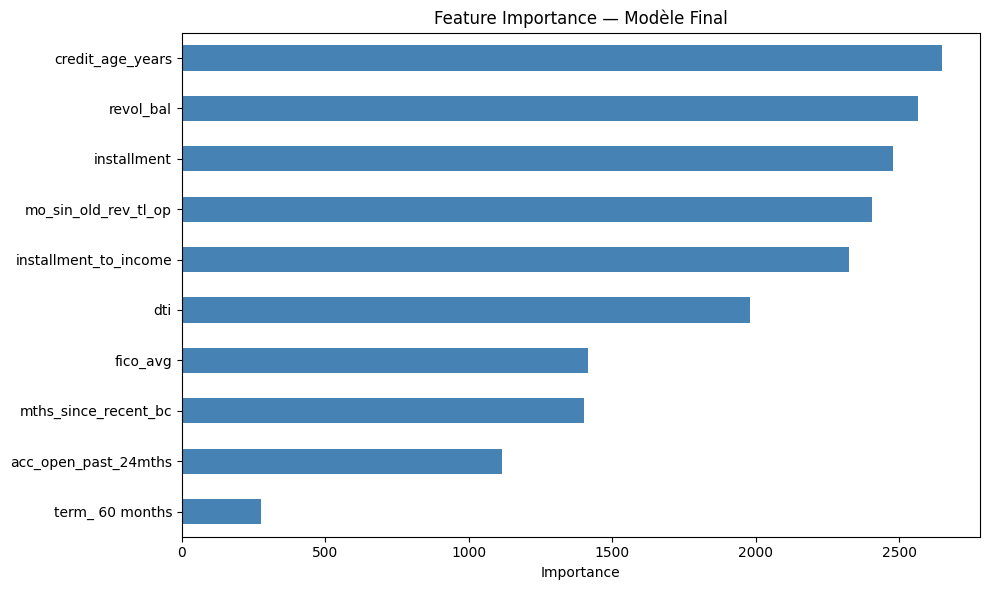

In [ ]:
# Feature Importance du modèle final
importances_final = pd.Series(best_model.feature_importances_,
                               index=test_X_selected.columns)
importances_final = importances_final.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_final.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Modèle Final")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# (Optionnel) SHAP Values
# import shap
# explainer = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(test_X_selected)
# shap.summary_plot(shap_values[1], test_X_selected)

In [ ]:
# Conclusions et Recommandations
# Résumer :
# 1. Les performances du modèle final (AUC, F1, KS, etc.)
# 2. Les 5 variables les plus influentes et leur interprétation métier
# 3. Les recommandations concrètes pour l'institution financière
# 4. Les limites du modèle et les pistes d'amélioration